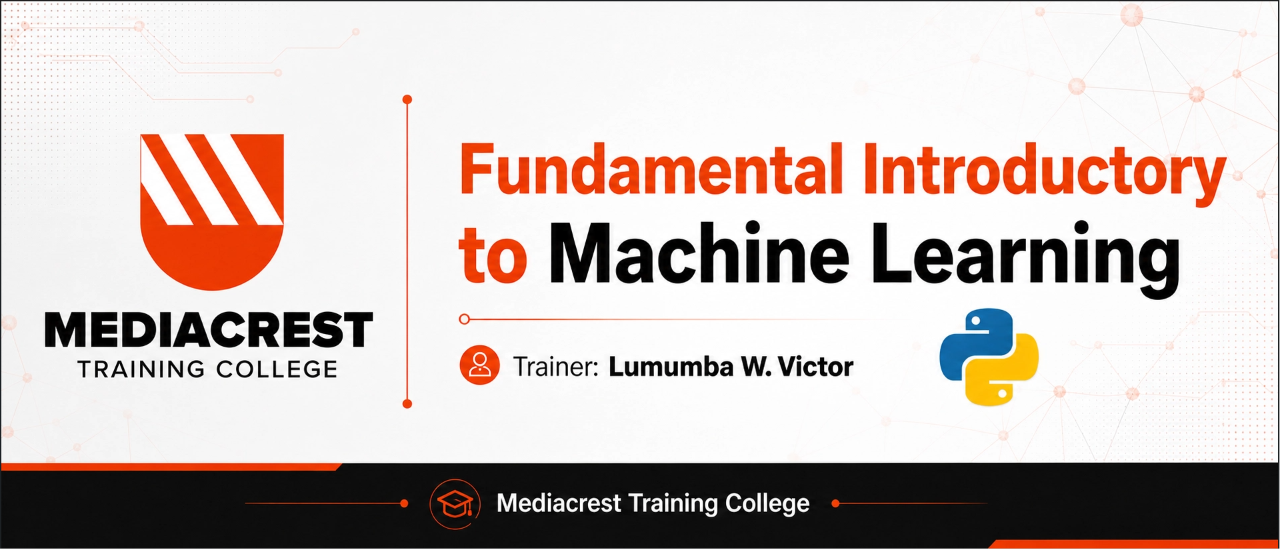

## **FUNDAMENTAL INTRODUCTORY TO MACHINE LEARNING**

### **1: PROBLEM FORMULATION**
> ##### **Clinical Objetive: Predict the Presence or Absence of Athelosclerotci Heart Disease (AHD) to enable early detection and risk stratification**

### **2: LOAD THE REQUIRED LIBRARIES AND DATA SET FOR EXPLORATORY DATA ANALYSIS**

In [ ]:
!pip install xgboost

In [21]:
#### Data Importation and Visualization Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#### Machine Learning Functionalities
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, learning_curve
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

#### Machine Learning Performance Functionalities
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, auc,
RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay)


#### Functionality for Extreme Gradient Boosting
import xgboost as xgb

#### **2.1. ENSURING REPRODUCIBILITY AND UNNECESSARY FILTERING WARNINGS**

In [24]:
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

### **2.2. LOADING THE REQUIRED DATASET**

In [25]:
df = pd.read_csv("Heart.csv", na_values = ['NA', '?', ''])
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,HD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No,0


### **3. EXPLORATORY DATA ANALYSIS**

#### **3.1. CHECK THE SHAPE AND DATA DISTRIBUTION**

In [27]:
dir(df)

['AHD',
 'Age',
 'Ca',
 'ChestPain',
 'Chol',
 'ExAng',
 'Fbs',
 'HD',
 'MaxHR',
 'Oldpeak',
 'RestBP',
 'RestECG',
 'Sex',
 'Slope',
 'T',
 'Thal',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__arrow_c_stream__',
 '__bool__',
 '__class__',
 '__contains__',
 '__copy__',
 '__dataframe__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',

In [26]:
print(f"Shape: {df.shape}")

Shape: (303, 15)


In [28]:
print(f"Column Names: {list(df.columns)}")

Column Names: ['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD', 'HD']


#### **3.2. CHECK THE NUMBER OF MISSING VALUES PER VARIABLE**

In [29]:
df.isna().sum()

Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal         2
AHD          0
HD           0
dtype: int64

#### **3.3 CHECK THE DISTRIBUTION OF CASES FOR THE TARGET VARIABLE**

In [30]:
df['AHD'].value_counts()

AHD
No     164
Yes    139
Name: count, dtype: int64

In [31]:
df['AHD']= df['AHD'].map({'No': 0, 
                         'Yes': 1})
print(df['AHD'].value_counts(normalize = True))

AHD
0    0.541254
1    0.458746
Name: proportion, dtype: float64


In [32]:
print(df['HD'].value_counts(normalize = True))

HD
0    0.541254
1    0.458746
Name: proportion, dtype: float64


#### **3.4. VISUALIZATION OF CASES FOR THE TARGET VARIABLE**

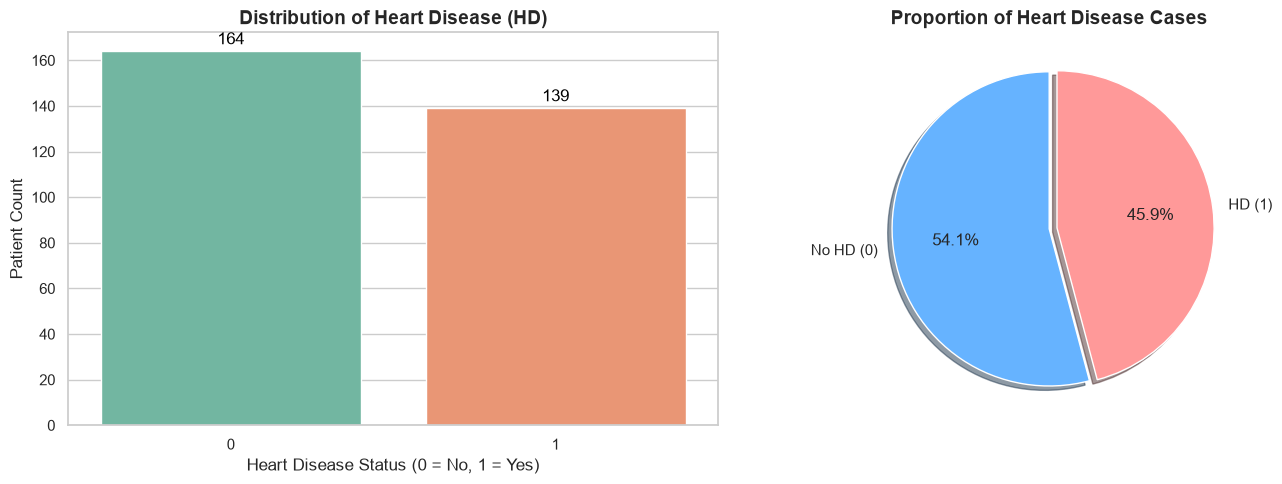

In [33]:
# Set global aesthetic
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A. Countplot
sns.countplot(x='HD', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Heart Disease (HD)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heart Disease Status (0 = No, 1 = Yes)')
axes[0].set_ylabel('Patient Count')
# Add count labels on top of bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), 
                     textcoords='offset points')

    # B. Pie Chart
hd_counts = df['HD'].value_counts()
axes[1].pie(hd_counts, labels=['No HD (0)', 'HD (1)'], autopct='%1.1f%%', 
            colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proportion of Heart Disease Cases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### **3.5. EXTRACTION OF TARGET VARABLE AND THE FEATURES**

In [34]:
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,HD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,0,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,1,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,1,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,0,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,0,0


In [35]:
X = df.drop(columns = ['AHD','HD'])
X.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal


In [36]:
y = df['AHD']
y.head()

0    0
1    1
2    1
3    0
4    0
Name: AHD, dtype: int64

#### **3.6.CATEGORIZE NUMERIC AND CATEGORICAL VARIABLES**

In [37]:
num_features = ['Age','RestBP', 'Chol', 'MaxHR', 'Oldpeak', 'Ca']
cat_features = ['Sex', 'ChestPain','Fbs', 'RestECG', 'ExAng', 'Slope', 'Thal']

### **4. DATA PREPROCESSING**

#### **4.1. Create Numeric Tranformer**

In [38]:
numeric_tranformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#### **4.2. Categorical Transformer**

In [42]:
categorical_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown = 'use_encoded_value',
                              unknown_value = -1))
])

#### **4.3. Create the Column Transformer**

In [43]:
preprocessor = ColumnTransformer(
    transformers =[
        ('num', numeric_tranformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder = 'drop'
)

### **5. DATA PARTITIONING**

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                   test_size = 0.2,
                                                   random_state = SEED,
                                                   stratify = y)

#### **5.1 Check the Proportion of the Cases in the Training and Testing Set**

In [48]:
train_dist = y_train.value_counts(normalize = True)
test_dist = y_test.value_counts(normalize = True)


proportion_df = pd.DataFrame({
    'Train (%)': train_dist,
    'Test ($)' : test_dist
})*100

proportion_df.round(2)

,Train (%),Test ($)
AHD,,
0,54.13,54.1
1,45.87,45.9


### **6. MODEL TRAINING AND HYPERPARAMETER TUNING**